## 0. Setup

In [28]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_05_01", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Rebuild Analytical Dataset

Rather than re-downloading from Azure, read the processed parquet files saved by EDA 02 and EDA 03, then re-run the spatial join and temporal filter. This keeps the EDA self-contained and fast.

In [29]:
from src.geo import find_nearby_stations

# Road closures — all and split by type
road_df            = pd.read_parquet("./data/processed/road_closures_clean.parquet")
unplanned_road_df  = pd.read_parquet("./data/processed/unplanned_road_closures.parquet")
planned_road_df    = pd.read_parquet("./data/processed/planned_road_closures.parquet")

# Train outputs from eda_03
train_station_day  = pd.read_parquet("./data/processed/train_station_day.parquet")
train_moments_df   = pd.read_parquet("./data/processed/train_moments_clean.parquet")

# Station reference for spatial join
stations_ref_df    = pd.read_parquet("./data/processed/stations_reference.parquet")

print("=== Input Shapes ===")
print(f"Road closures (all):       {len(road_df):,}")
print(f"Road closures (unplanned): {len(unplanned_road_df):,}")
print(f"Road closures (planned):   {len(planned_road_df):,}")
print(f"Train station-day:         {len(train_station_day):,}")
print(f"Train moments (clean):     {len(train_moments_df):,}")
print(f"Stations reference:        {len(stations_ref_df):,}")

print("\n=== Date Alignment Check ===")
print(f"Road closures:    {road_df['effective_start_time'].min()} — {road_df['effective_end_time'].max()}")
train_station_day["planned_date"] = pd.to_datetime(train_station_day["planned_date"])
print(f"Train station-day:{train_station_day['planned_date'].min()} — {train_station_day['planned_date'].max()}")

=== Input Shapes ===
Road closures (all):       1,557
Road closures (unplanned): 1,006
Road closures (planned):   551
Train station-day:         33,941
Train moments (clean):     212,884
Stations reference:        2,594

=== Date Alignment Check ===
Road closures:    2026-04-10 00:00:00+00:00 — 2026-04-28 23:59:59+00:00
Train station-day:2026-04-03 00:00:00 — 2026-04-28 00:00:00


## Spatial Join: Link All Closures to Nearby Stations (10–25 km)

In [30]:
expanded_road_df = find_nearby_stations(
    road_df, stations_ref_df, min_km=10, max_km=25
)

print(f"Closure-station pairs (all):       {len(expanded_road_df):,}")
print(f"Unique closures matched:           {expanded_road_df['closure_id'].nunique():,}")
print(f"Unique stations with any closure:  {expanded_road_df['station_name'].nunique():,}")
print(f"Unique stations total:             {stations_ref_df['station'].nunique():,}")
print(f"Coverage: {expanded_road_df['station_name'].nunique() / stations_ref_df['station'].nunique() * 100:.1f}% of stations have at least one nearby closure")

display(expanded_road_df[[
    "closure_id", "station_name", "distance_in_km",
    "closure_type", "road_name", "road_class", "closure_severity",
    "effective_start_time", "effective_end_time",
    "effective_duration_hours"
]].head(5))

Closure-station pairs (all):       99,298
Unique closures matched:           1,162
Unique stations with any closure:  1,744
Unique stations total:             2,594
Coverage: 67.2% of stations have at least one nearby closure


,closure_id,station_name,distance_in_km,closure_type,road_name,road_class,closure_severity,effective_start_time,effective_end_time,effective_duration_hours
0,481398,Dullingham,21.561992,planned,M11,3,30.0,2026-04-11 19:00:00,2026-04-12 05:00:00,10.0
1,481398,Ely,21.974512,planned,M11,3,30.0,2026-04-11 19:00:00,2026-04-12 05:00:00,10.0
2,481398,Foxton,13.545760,planned,M11,3,30.0,2026-04-11 19:00:00,2026-04-12 05:00:00,10.0
3,481398,Great Chesterford,22.207451,planned,M11,3,30.0,2026-04-11 19:00:00,2026-04-12 05:00:00,10.0
4,481398,Huntingdon,19.527520,planned,M11,3,30.0,2026-04-11 19:00:00,2026-04-12 05:00:00,10.0


In [31]:
# Spatial join — unplanned closures separately for closure-hour analysis
expanded_unplanned_df = find_nearby_stations(
    unplanned_road_df, stations_ref_df, min_km=10, max_km=25
)

print(f"Closure-station pairs (unplanned): {len(expanded_unplanned_df):,}")
print(f"Unique unplanned closures matched: {expanded_unplanned_df['closure_id'].nunique():,}")
print(f"Unique stations near unplanned:    {expanded_unplanned_df['station_name'].nunique():,}")

Closure-station pairs (unplanned): 75,415
Unique unplanned closures matched: 973
Unique stations near unplanned:    1,479


## Expand Closures Across Active Days

In [32]:
def expand_closures_to_days(df):
    """
    Explode each closure across every calendar day it is active.
    A closure running Apr 10-14 becomes 5 rows, one per day.
    This bridges the temporal granularity gap between road closures
    (spanning days) and train movements (per-second).
    """
    df = df.copy()
    df["effective_start_time"] = pd.to_datetime(
        df["effective_start_time"], utc=True, errors="coerce"
    )
    df["effective_end_time"] = pd.to_datetime(
        df["effective_end_time"], utc=True, errors="coerce"
    )
    df = df.dropna(
        subset=["effective_start_time", "effective_end_time", "station_name"]
    )
    df["planned_date"] = df.apply(
        lambda row: pd.date_range(
            row["effective_start_time"].floor("D"),
            row["effective_end_time"].floor("D"),
            freq="D",
        ),
        axis=1,
    )
    df = df.explode("planned_date").copy()
    df["planned_date"] = pd.to_datetime(df["planned_date"]).dt.date
    return df

road_station_day          = expand_closures_to_days(expanded_road_df)
unplanned_station_day     = expand_closures_to_days(expanded_unplanned_df)

print(f"Road station-day rows (all):       {len(road_station_day):,}")
print(f"Road station-day rows (unplanned): {len(unplanned_station_day):,}")
display(road_station_day.head(3))

Road station-day rows (all):       347,231
Road station-day rows (unplanned): 75,709


,closure_id,closure_type,closure_start_time,closure_end_time,road_name,road_class,closure_severity,start_hour,start_dow,start_date,duration_hours,effective_duration_hours,effective_end_time,effective_start_time,validity_status,cause_type,station_name,station_code,stanox,tpl,distance_in_km,planned_date
0,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,M11,3,30.0,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00+00:00,2026-04-11 19:00:00+00:00,planned,roadMaintenance,Dullingham,DUL,47006,DULNGHM,21.561992,2026-04-11
0,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,M11,3,30.0,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00+00:00,2026-04-11 19:00:00+00:00,planned,roadMaintenance,Dullingham,DUL,47006,DULNGHM,21.561992,2026-04-12
1,481398,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,M11,3,30.0,19,5,2026-04-11,10.0,10.0,2026-04-12 05:00:00+00:00,2026-04-11 19:00:00+00:00,planned,roadMaintenance,Ely,ELY,46273,ELYY,21.974512,2026-04-11


## Closure-Hour Tagging (Spatial + Temporal)

In [33]:
# For each unplanned closure-station pair, filter train_moments_clean
# to movements at that station whose actual_timestamp falls within
# the closure's effective_start_time and effective_end_time.
#
# This is the precise window analysis - not just "was there a closure today"
# but "was this train moving during the specific hours the closure was active
# at a nearby station"

# Ensure timestamps are UTC-aware in train moments
train_moments_df["actual_timestamp"] = pd.to_datetime(
    train_moments_df["actual_timestamp"], utc=True, errors="coerce"
)

# Build station-level closure window lookup for unplanned closures
# station_name → list of (start, end, closure_id) tuples
station_closure_windows = (
    expanded_unplanned_df
    .dropna(subset=["effective_start_time", "effective_end_time"])
    .assign(
        effective_start_time=lambda d: pd.to_datetime(
            d["effective_start_time"], utc=True
        ),
        effective_end_time=lambda d: pd.to_datetime(
            d["effective_end_time"], utc=True
        ),
    )
    .groupby("station_name")
    .apply(lambda g: list(zip(
        g["effective_start_time"],
        g["effective_end_time"],
        g["closure_id"]
    )))
    .to_dict()
)

print(f"Stations with unplanned closure windows: {len(station_closure_windows):,}")

def is_during_unplanned_closure(row):
    windows = station_closure_windows.get(row["station_name"], [])
    if not windows or pd.isna(row["actual_timestamp"]):
        return 0
    t = row["actual_timestamp"]
    return int(any(start <= t <= end for start, end, _ in windows))

print("Tagging movements during unplanned closure windows...")
train_moments_df["during_unplanned_closure"] = train_moments_df.apply(
    is_during_unplanned_closure, axis=1
)

n_tagged = train_moments_df["during_unplanned_closure"].sum()
print(f"Movements during unplanned closure: {n_tagged:,} ({n_tagged/len(train_moments_df)*100:.1f}%)")
print(f"Movements outside closure:          {len(train_moments_df) - n_tagged:,}")

Stations with unplanned closure windows: 1,479
Tagging movements during unplanned closure windows...
Movements during unplanned closure: 4,581 (2.2%)
Movements outside closure:          208,303


## Aggregate Closure-Hour Delay Metrics

In [34]:
# Aggregate delay metrics for movements during unplanned closure windows only
# These become additional model features — directly operationalises the
# requirement to analyse movements during road closure hours

closure_hour_agg = (
    train_moments_df[train_moments_df["during_unplanned_closure"] == 1]
    .dropna(subset=["station_name"])
    .groupby(["station_name", "loc_stanox", "planned_date"], dropna=False)
    .agg(
        movements_during_closure  = ("planned_timestamp", "count"),
        mean_delay_during_closure = ("delay_minutes",     "mean"),
        pct_late_during_closure   = ("is_late",           "mean"),
        max_delay_during_closure  = ("late_minutes",      "max"),
        pct_delayed_5min_during   = ("is_delayed_5min",   "mean"),
    )
    .reset_index()
    .rename(columns={"loc_stanox": "stanox"})
)

closure_hour_agg["stanox"] = closure_hour_agg["stanox"].apply(
    lambda x: str(int(x)) if pd.notna(x) else None
)
closure_hour_agg["planned_date"] = pd.to_datetime(closure_hour_agg["planned_date"])

print(f"Station-days with movements during unplanned closures: {len(closure_hour_agg):,}")
print(f"Unique stations:                                       {closure_hour_agg['station_name'].nunique():,}")
display(closure_hour_agg.head(3))

Station-days with movements during unplanned closures: 2,877
Unique stations:                                       947


,station_name,stanox,planned_date,movements_during_closure,mean_delay_during_closure,pct_late_during_closure,max_delay_during_closure,pct_delayed_5min_during
0,Abbey Wood,88601,2026-04-16,1,0.0,0.0,0.0,0.0
1,Abbey Wood,88601,2026-04-23,1,1.0,1.0,1.0,0.0
2,Abbey Wood,88601,2026-04-27,1,1.5,1.0,1.5,0.0


## Aggregate Road Closures to Station-Day Level

In [35]:
ROAD_CLASS_WEIGHT = {"M": 3, "A": 2, "B": 1}

road_station_day_agg = (
    road_station_day
    .groupby(["station_name", "stanox", "planned_date"], dropna=False)
    .agg(
        road_closure_count            = ("closure_id",               "nunique"),
        min_distance_km               = ("distance_in_km",           "min"),
        mean_distance_km              = ("distance_in_km",           "mean"),
        max_effective_duration_hours  = ("effective_duration_hours", "max"),
        mean_effective_duration_hours = ("effective_duration_hours", "mean"),
        # Closer closures contribute more signal
        inv_distance_sum              = ("distance_in_km",           lambda x: (1 / x).sum()),
        # Road-class-weighted severity
        total_closure_severity        = ("closure_severity",         "sum"),
        max_road_class                = ("road_class",               "max"),
    )
    .reset_index()
)

# Unplanned closures counted separately
n_unplanned = (
    road_station_day[road_station_day["closure_type"] == "unplanned"]
    .groupby(["station_name", "stanox", "planned_date"])["closure_id"]
    .nunique()
    .reset_index(name="n_unplanned_closures")
)
road_station_day_agg = road_station_day_agg.merge(
    n_unplanned, on=["station_name", "stanox", "planned_date"], how="left"
)
road_station_day_agg["n_unplanned_closures"] = (
    road_station_day_agg["n_unplanned_closures"].fillna(0).astype(int)
)
road_station_day_agg["has_road_closure"] = (
    road_station_day_agg["road_closure_count"] > 0
).astype(int)

road_station_day_agg["planned_date"] = pd.to_datetime(road_station_day_agg["planned_date"])

print(f"Aggregated road station-day rows: {len(road_station_day_agg):,}")
display(road_station_day_agg.head(3))

Aggregated road station-day rows: 26,658


,station_name,stanox,planned_date,road_closure_count,min_distance_km,mean_distance_km,max_effective_duration_hours,mean_effective_duration_hours,inv_distance_sum,total_closure_severity,max_road_class,n_unplanned_closures,has_road_closure
0,Abbey Wood,88601,2026-04-10,7,10.191189,18.115876,6.5,2.357143,0.414091,49.50,3,4,1
1,Abbey Wood,88601,2026-04-11,3,13.397358,18.104797,8.0,4.916667,0.176387,44.25,3,1,1
2,Abbey Wood,88601,2026-04-12,3,11.301188,17.208552,8.0,5.791667,0.381811,91.25,3,1,1


## Train Station-Day + Road Features

In [36]:
# Left join preserves station-days with NO nearby closures as negative examples
# Without these, the classifier cannot learn what "normal" looks like
station_day_df = train_station_day.merge(
    road_station_day_agg,
    on=["station_name", "stanox", "planned_date"],
    how="left"
)

ROAD_COLS = [
    "road_closure_count", "n_unplanned_closures",
    "min_distance_km", "mean_distance_km",
    "max_effective_duration_hours", "mean_effective_duration_hours",
    "inv_distance_sum", "total_closure_severity",
    "max_road_class", "has_road_closure",
]
for col in ROAD_COLS:
    if col in station_day_df.columns:
        station_day_df[col] = station_day_df[col].fillna(0)

print(f"Merged dataset shape: {station_day_df.shape}")
print(f"Rows with closure:    {station_day_df['has_road_closure'].sum():,} ({station_day_df['has_road_closure'].mean()*100:.1f}%)")
print(f"Rows without closure: {(station_day_df['has_road_closure'] == 0).sum():,} ({(1 - station_day_df['has_road_closure'].mean())*100:.1f}%)")

Merged dataset shape: (33941, 27)
Rows with closure:    19,991.0 (58.9%)
Rows without closure: 13,950 (41.1%)


## Merge Closure-Hour Metrics

In [37]:
# Bring in closure-hour delay metrics as additional model features
station_day_df = station_day_df.merge(
    closure_hour_agg[[
        "station_name", "stanox", "planned_date",
        "movements_during_closure",
        "mean_delay_during_closure",
        "pct_late_during_closure",
        "max_delay_during_closure",
        "pct_delayed_5min_during",
    ]],
    on=["station_name", "stanox", "planned_date"],
    how="left"
)

CLOSURE_HOUR_COLS = [
    "movements_during_closure", "mean_delay_during_closure",
    "pct_late_during_closure", "max_delay_during_closure",
    "pct_delayed_5min_during",
]
for col in CLOSURE_HOUR_COLS:
    station_day_df[col] = station_day_df[col].fillna(0)

print(f"Station-days with closure-hour metrics: "
      f"{(station_day_df['movements_during_closure'] > 0).sum():,}")
display(station_day_df[CLOSURE_HOUR_COLS].describe().round(3))

Station-days with closure-hour metrics: 2,877


,movements_during_closure,mean_delay_during_closure,pct_late_during_closure,max_delay_during_closure,pct_delayed_5min_during
count,33941.000,33941.000,33941.000,33941.000,33941.000
mean,0.135,0.092,0.038,0.195,0.007
std,0.563,1.025,0.183,1.856,0.077
min,0.000,-8.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000
75%,0.000,0.000,0.000,0.000,0.000
max,15.000,22.500,1.000,114.500,1.000


## Temporal Features

In [38]:
station_day_df["day_of_week"] = station_day_df["planned_date"].dt.dayofweek
station_day_df["is_weekend"]  = station_day_df["day_of_week"].isin([5, 6]).astype(int)
station_day_df["is_monday"]   = (station_day_df["day_of_week"] == 0).astype(int)
station_day_df["is_friday"]   = (station_day_df["day_of_week"] == 4).astype(int)

print("Disruption rate by day of week:")
DOW_MAP = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
dow = (
    station_day_df
    .groupby("day_of_week")["mean_delay_minutes"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "mean_delay", "count": "n_days"})
)
dow.index = [DOW_MAP[i] for i in dow.index]
display(dow.round(3))

Disruption rate by day of week:


,mean_delay,n_days
Mon,0.958,6322
Tue,0.752,6029
Wed,0.721,1976
Thu,0.903,4276
Fri,1.350,6070
Sat,0.545,3639
Sun,0.921,5629


## Lag Features

In [39]:
# Rolling closure counts from previous days at the same station
# Gives the model temporal memory — sustained road pressure vs one-off event
station_day_df = station_day_df.sort_values(
    ["station_name", "planned_date"]
).reset_index(drop=True)

for window in [1, 3, 7]:
    station_day_df[f"closures_lag{window}d"] = (
        station_day_df
        .groupby("station_name")["road_closure_count"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).sum())
        .fillna(0)
    )

print("Lag features added:")
print(station_day_df[[
    "station_name", "planned_date", "road_closure_count",
    "closures_lag1d", "closures_lag3d", "closures_lag7d"
]].head(8).to_string())

Lag features added:
  station_name planned_date  road_closure_count  closures_lag1d  closures_lag3d  closures_lag7d
0   Abbey Wood   2026-04-10                 7.0             0.0             0.0             0.0
1   Abbey Wood   2026-04-11                 3.0             7.0             7.0             7.0
2   Abbey Wood   2026-04-12                 3.0             3.0            10.0            10.0
3   Abbey Wood   2026-04-13                 3.0             3.0            13.0            13.0
4   Abbey Wood   2026-04-14                 3.0             3.0             9.0            16.0
5   Abbey Wood   2026-04-15                 2.0             3.0             9.0            19.0
6   Abbey Wood   2026-04-16                 6.0             2.0             8.0            21.0
7   Abbey Wood   2026-04-17                 3.0             6.0            11.0            27.0


# Dataset Summary

In [40]:
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)
print(f"Total rows:              {len(station_day_df):,}")
print(f"Unique stations:         {station_day_df['station_name'].nunique():,}")
print(f"Date range:              {station_day_df['planned_date'].min().date()} to {station_day_df['planned_date'].max().date()}")
print(f"With any closure:        {station_day_df['has_road_closure'].sum():,} ({station_day_df['has_road_closure'].mean()*100:.1f}%)")
print(f"With unplanned closure:  {(station_day_df['n_unplanned_closures'] > 0).sum():,} ({(station_day_df['n_unplanned_closures'] > 0).mean()*100:.1f}%)")
print(f"With closure-hour data:  {(station_day_df['movements_during_closure'] > 0).sum():,}")
print()

dupes = (
    station_day_df
    .groupby(["station_name", "stanox", "planned_date"])
    .size()
    .pipe(lambda s: s[s > 1])
)
print(f"Duplicate station-day rows: {len(dupes):,}")

FINAL DATASET SUMMARY
Total rows:              33,941
Unique stations:         2,506
Date range:              2026-04-03 to 2026-04-28
With any closure:        19,991.0 (58.9%)
With unplanned closure:  15,040 (44.3%)
With closure-hour data:  2,877

Duplicate station-day rows: 0


# EDA
## Delay Distribution

Delay statistics (minutes):
count    33941.000
mean         0.921
std          2.634
min         -8.000
25%         -0.375
50%          0.300
75%          1.500
max         22.500
Name: mean_delay_minutes, dtype: float64

Skewness: 2.946   Kurtosis: 16.990

Quantiles:
0.01    -4.00
0.05    -1.25
0.25    -0.38
0.50     0.30
0.75     1.50
0.95     5.50
0.99    11.50
Name: mean_delay_minutes, dtype: float64


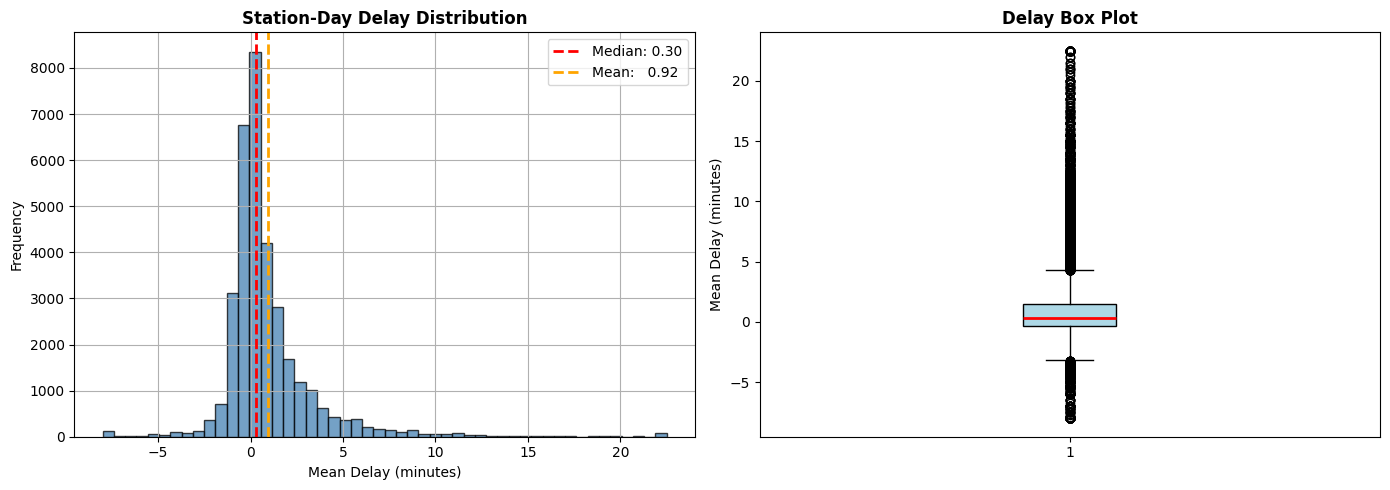

In [41]:
delay = station_day_df["mean_delay_minutes"]
print("Delay statistics (minutes):")
print(delay.describe().round(3))
print(f"\nSkewness: {delay.skew():.3f}   Kurtosis: {delay.kurtosis():.3f}")
print(f"\nQuantiles:")
print(delay.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delay.hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(delay.median(), color="red",    linestyle="--", lw=2,
                label=f"Median: {delay.median():.2f}")
axes[0].axvline(delay.mean(),   color="orange", linestyle="--", lw=2,
                label=f"Mean:   {delay.mean():.2f}")
axes[0].set_xlabel("Mean Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Station-Day Delay Distribution", fontweight="bold")
axes[0].legend()

axes[1].boxplot(delay.dropna(), patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].set_title("Delay Box Plot", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_05_01/delay_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## Full Correlation Matrix

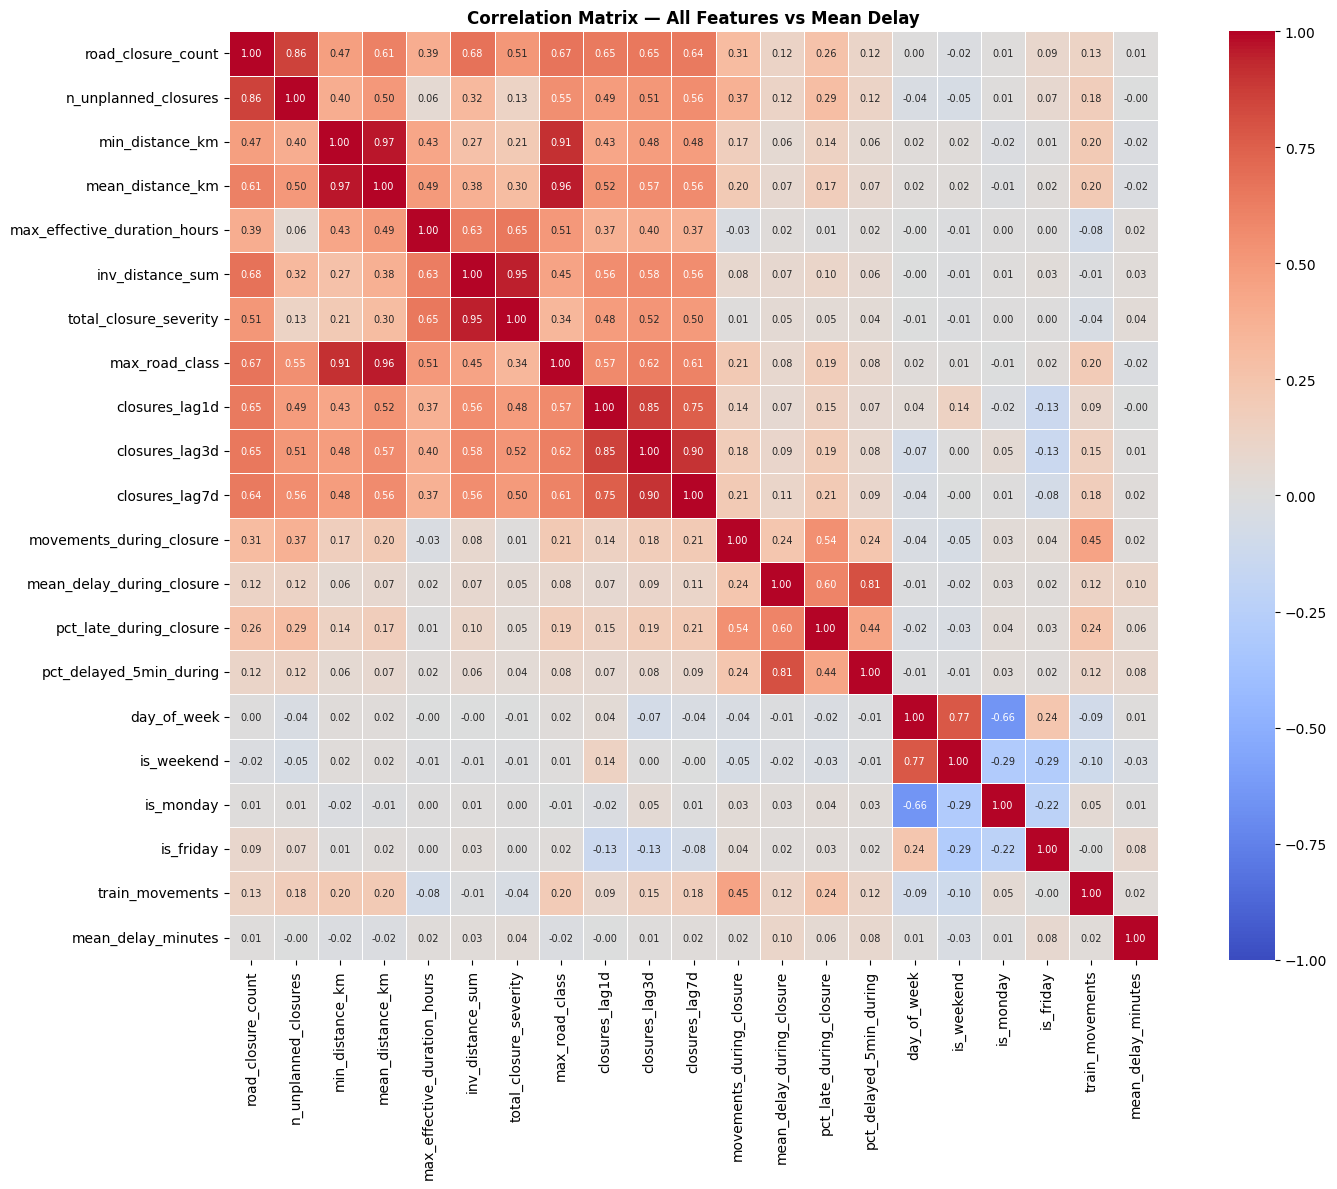


Correlation with mean_delay_minutes (sorted):
is_weekend                     -0.0342
min_distance_km                -0.0213
mean_distance_km               -0.0178
max_road_class                 -0.0164
n_unplanned_closures           -0.0035
closures_lag1d                 -0.0018
is_monday                       0.0068
day_of_week                     0.0084
closures_lag3d                  0.0108
road_closure_count              0.0113
movements_during_closure        0.0167
closures_lag7d                  0.0188
max_effective_duration_hours    0.0209
train_movements                 0.0248
inv_distance_sum                0.0311
total_closure_severity          0.0364
pct_late_during_closure         0.0576
is_friday                       0.0761
pct_delayed_5min_during         0.0840
mean_delay_during_closure       0.1024
Name: mean_delay_minutes, dtype: float64


In [42]:
FEATURE_COLS = [
    # Road closure features
    "road_closure_count", "n_unplanned_closures",
    "min_distance_km", "mean_distance_km",
    "max_effective_duration_hours", "inv_distance_sum",
    "total_closure_severity", "max_road_class",
    # Lag features
    "closures_lag1d", "closures_lag3d", "closures_lag7d",
    # Closure-hour features
    "movements_during_closure", "mean_delay_during_closure",
    "pct_late_during_closure", "pct_delayed_5min_during",
    # Temporal features
    "day_of_week", "is_weekend", "is_monday", "is_friday",
    # Train volume
    "train_movements",
    # Target
    "mean_delay_minutes",
]

existing = [c for c in FEATURE_COLS if c in station_day_df.columns]
corr = station_day_df[existing].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.4, vmin=-1, vmax=1,
    annot_kws={"size": 7}
)
plt.title("Correlation Matrix — All Features vs Mean Delay", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_05_01/correlation_matrix_full.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nCorrelation with mean_delay_minutes (sorted):")
print(corr["mean_delay_minutes"].drop("mean_delay_minutes").sort_values().round(4))

## Delay During vs Outside Closure Hours

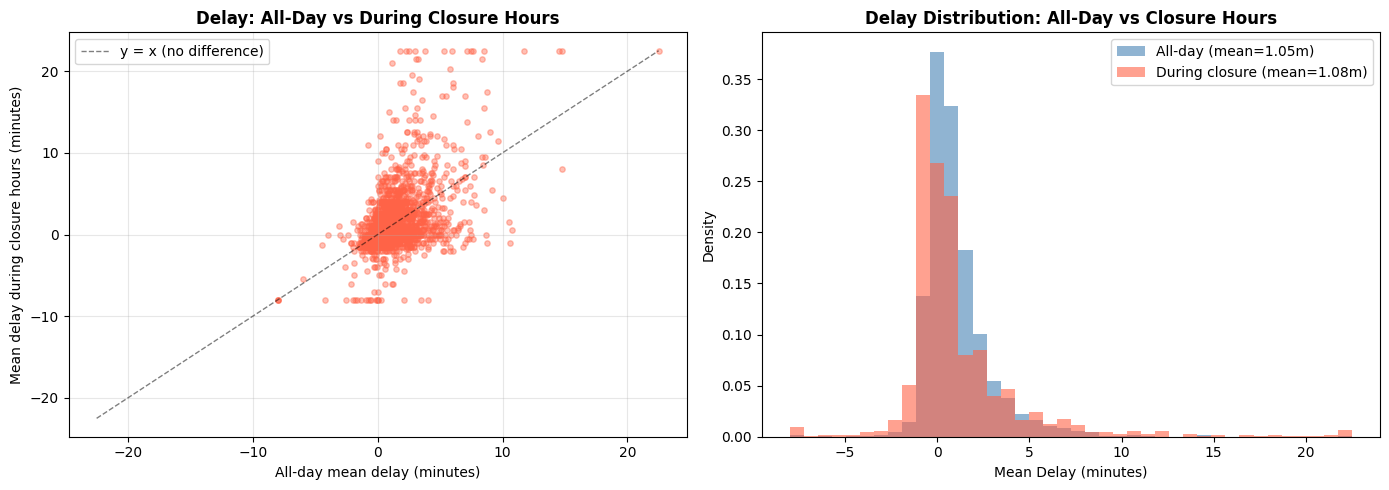

Summary: stations with movements during unplanned closure windows
  Station-days:                2,877
  All-day mean delay:          1.046 min
  Closure-hour mean delay:     1.083 min
  Closure-hour % late:         45.3%
  Closure-hour % delayed >5m:  8.3%


In [43]:
# Spatially filtered comparison — the correct version of the hypothesis test
# Each station is compared against itself: during its own nearby closure hours
# vs all other hours. This removes the confound of comparing different stations.

has_closure_data = station_day_df[
    station_day_df["movements_during_closure"] > 0
].copy()

if len(has_closure_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Mean delay: during vs all-day at same stations
    axes[0].scatter(
        has_closure_data["mean_delay_minutes"],
        has_closure_data["mean_delay_during_closure"],
        alpha=0.4, s=15, color="tomato"
    )
    lim = max(
        has_closure_data["mean_delay_minutes"].abs().max(),
        has_closure_data["mean_delay_during_closure"].abs().max()
    )
    axes[0].plot([-lim, lim], [-lim, lim], "k--", lw=1, alpha=0.5,
                 label="y = x (no difference)")
    axes[0].set_xlabel("All-day mean delay (minutes)")
    axes[0].set_ylabel("Mean delay during closure hours (minutes)")
    axes[0].set_title("Delay: All-Day vs During Closure Hours", fontweight="bold")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Distribution comparison
    axes[1].hist(
        has_closure_data["mean_delay_minutes"],
        bins=40, alpha=0.6, color="steelblue", density=True,
        label=f"All-day (mean={has_closure_data['mean_delay_minutes'].mean():.2f}m)"
    )
    axes[1].hist(
        has_closure_data["mean_delay_during_closure"],
        bins=40, alpha=0.6, color="tomato", density=True,
        label=f"During closure (mean={has_closure_data['mean_delay_during_closure'].mean():.2f}m)"
    )
    axes[1].set_xlabel("Mean Delay (minutes)")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Delay Distribution: All-Day vs Closure Hours", fontweight="bold")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("figures/eda_05_01/delay_during_vs_allday.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Summary table
    print("Summary: stations with movements during unplanned closure windows")
    print(f"  Station-days:                {len(has_closure_data):,}")
    print(f"  All-day mean delay:          {has_closure_data['mean_delay_minutes'].mean():.3f} min")
    print(f"  Closure-hour mean delay:     {has_closure_data['mean_delay_during_closure'].mean():.3f} min")
    print(f"  Closure-hour % late:         {has_closure_data['pct_late_during_closure'].mean()*100:.1f}%")
    print(f"  Closure-hour % delayed >5m:  {has_closure_data['pct_delayed_5min_during'].mean()*100:.1f}%")
else:
    print("No movements tagged during unplanned closure windows.")
    print("Check that unplanned_road_closures.parquet has rows and timestamps align.")

## Disruption Rate by Road Class and Closure Type

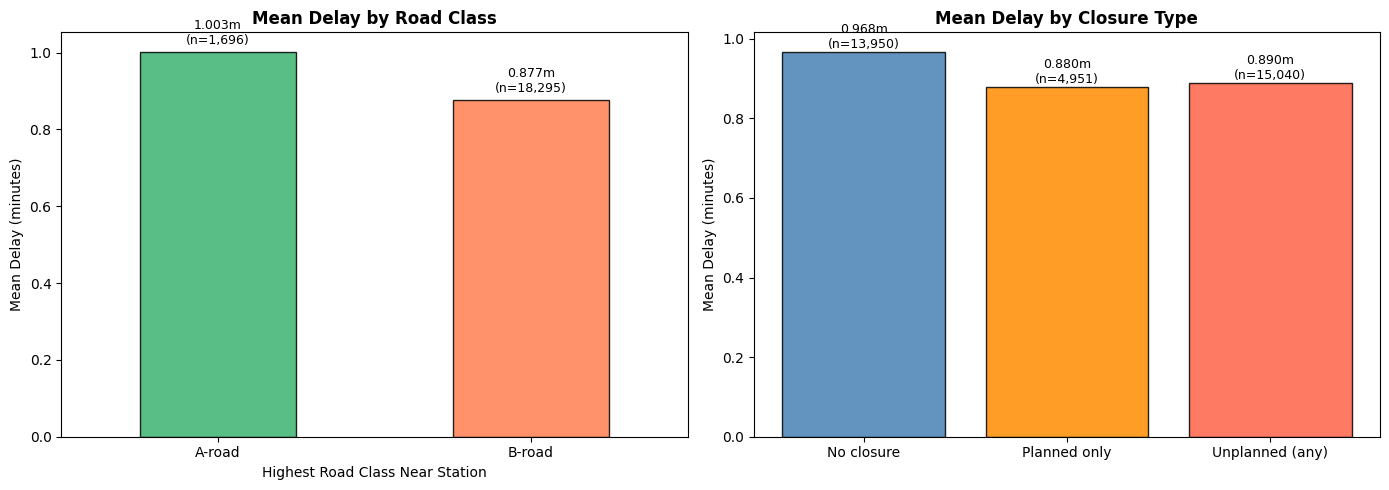

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean delay by max road class at station-day
if "max_road_class" in station_day_df.columns:
    rc = (
        station_day_df[station_day_df["has_road_closure"] == 1]
        .groupby("max_road_class")["mean_delay_minutes"]
        .agg(["mean", "count"])
        .rename(index={1: "Motorway (M)", 2: "A-road", 3: "B-road"})
    )
    rc["mean"].plot(kind="bar", ax=axes[0], color=["mediumseagreen", "coral", "steelblue"],
                   edgecolor="black", alpha=0.85)
    axes[0].set_title("Mean Delay by Road Class", fontweight="bold")
    axes[0].set_ylabel("Mean Delay (minutes)")
    axes[0].set_xlabel("Highest Road Class Near Station")
    axes[0].tick_params(axis="x", rotation=0)
    for i, (v, c) in enumerate(zip(rc["mean"], rc["count"])):
        axes[0].text(i, v + 0.02, f"{v:.3f}m\n(n={c:,})", ha="center", fontsize=9)

# Mean delay: planned vs unplanned closure days
has_unplanned = station_day_df["n_unplanned_closures"] > 0
has_planned   = (station_day_df["road_closure_count"] > station_day_df["n_unplanned_closures"])
no_closure    = station_day_df["has_road_closure"] == 0

groups = {
    "No closure":       station_day_df[no_closure]["mean_delay_minutes"],
    "Planned only":     station_day_df[has_planned & ~has_unplanned]["mean_delay_minutes"],
    "Unplanned (any)":  station_day_df[has_unplanned]["mean_delay_minutes"],
}
means  = {k: v.mean() for k, v in groups.items()}
counts = {k: len(v)   for k, v in groups.items()}

axes[1].bar(means.keys(), means.values(),
            color=["steelblue", "darkorange", "tomato"],
            edgecolor="black", alpha=0.85)
axes[1].set_title("Mean Delay by Closure Type", fontweight="bold")
axes[1].set_ylabel("Mean Delay (minutes)")
axes[1].tick_params(axis="x", rotation=0)
for i, (k, v) in enumerate(means.items()):
    axes[1].text(i, v + 0.01, f"{v:.3f}m\n(n={counts[k]:,})",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/eda_05_01/delay_by_road_class_and_type.png", dpi=200, bbox_inches="tight")
plt.show()

## Delay by Day of Week and Closure Presence

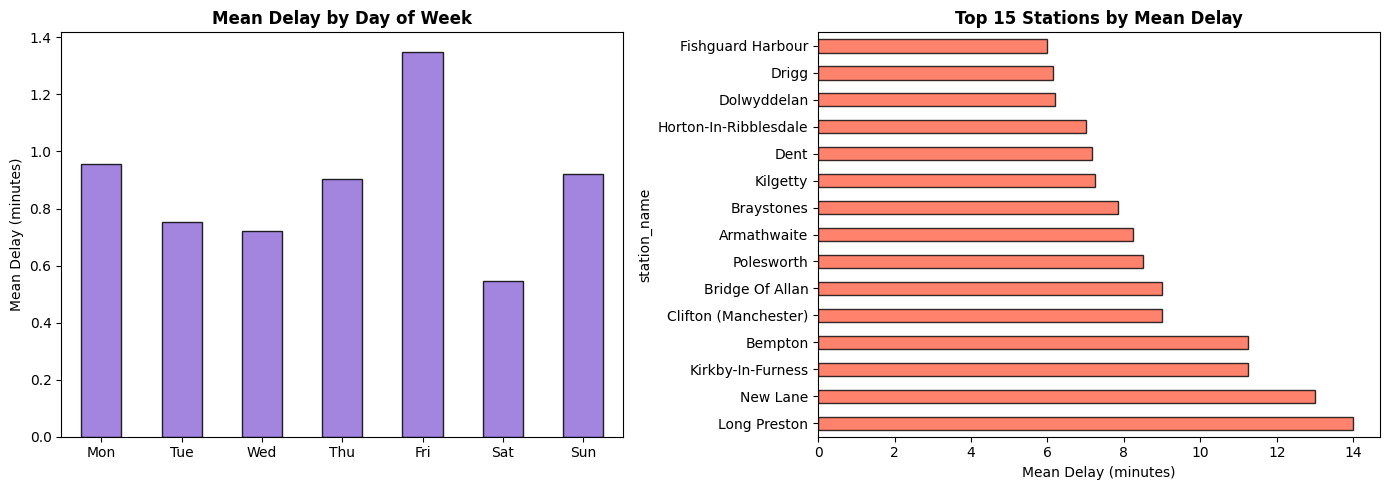

In [45]:
DOW_MAP = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean delay by day of week — baseline temporal pattern
dow_delay = station_day_df.groupby("day_of_week")["mean_delay_minutes"].mean()
dow_delay.index = [DOW_MAP[i] for i in dow_delay.index]
dow_delay.plot(kind="bar", ax=axes[0], color="mediumpurple",
               edgecolor="black", alpha=0.85)
axes[0].set_title("Mean Delay by Day of Week", fontweight="bold")
axes[0].set_ylabel("Mean Delay (minutes)")
axes[0].tick_params(axis="x", rotation=0)

# Top 15 stations by mean delay
top_delay_stations = (
    station_day_df.groupby("station_name")["mean_delay_minutes"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)
top_delay_stations.plot(kind="barh", ax=axes[1], color="tomato",
                        edgecolor="black", alpha=0.8)
axes[1].set_title("Top 15 Stations by Mean Delay", fontweight="bold")
axes[1].set_xlabel("Mean Delay (minutes)")

plt.tight_layout()
plt.savefig("figures/eda_05_01/temporal_and_station_delay.png", dpi=200, bbox_inches="tight")
plt.show()

## Top Stations by Record Count

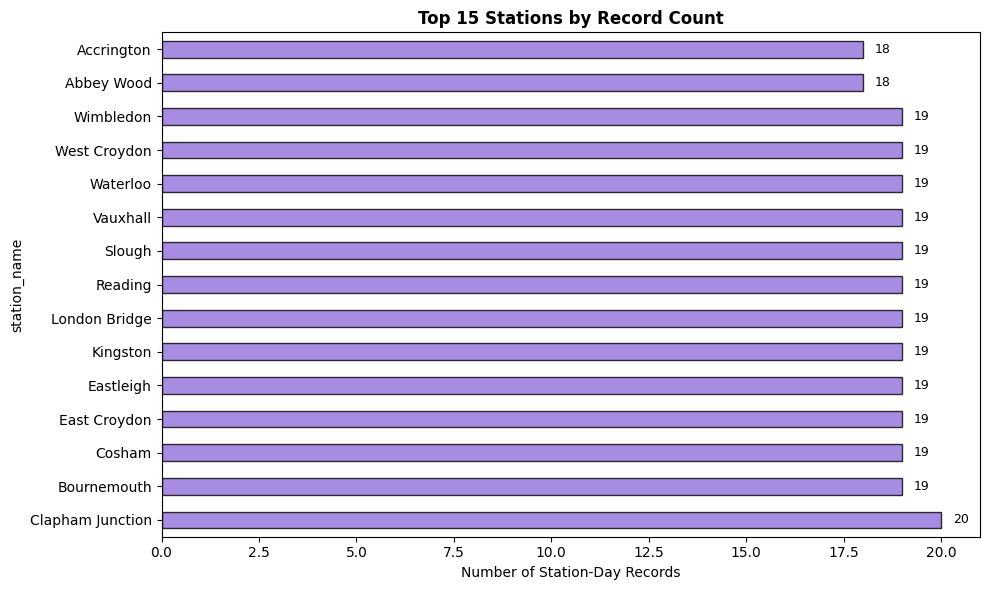

In [46]:
top_stations = station_day_df["station_name"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
plt.xlabel("Number of Station-Day Records")
plt.title("Top 15 Stations by Record Count", fontweight="bold")
for i, v in enumerate(top_stations.values):
    plt.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/eda_05_01/top_stations.png", dpi=200, bbox_inches="tight")
plt.show()

## Save Final Analytical Dataset

In [47]:
OUT_PATH = "./data/processed/road_station_day_dataset.parquet"
station_day_df.to_parquet(OUT_PATH, index=False)

print(f"Saved: {OUT_PATH}")
print(f"Shape: {station_day_df.shape}")
print(f"\nFinal columns ({len(station_day_df.columns)}):")
print(list(station_day_df.columns))
print()
station_day_df.info()

Saved: ./data/processed/road_station_day_dataset.parquet
Shape: (33941, 39)

Final columns (39):
['station_name', 'stanox', 'planned_date', 'train_movements', 'mean_delay_minutes', 'median_delay_minutes', 'late_movements', 'mean_late_minutes', 'max_late_minutes', 'early_movements', 'mean_early_minutes', 'delayed_movements_5min', 'severe_delay_movements_15min', 'late_share', 'early_share', 'delayed_share_5min', 'severe_delay_share_15min', 'road_closure_count', 'min_distance_km', 'mean_distance_km', 'max_effective_duration_hours', 'mean_effective_duration_hours', 'inv_distance_sum', 'total_closure_severity', 'max_road_class', 'n_unplanned_closures', 'has_road_closure', 'movements_during_closure', 'mean_delay_during_closure', 'pct_late_during_closure', 'max_delay_during_closure', 'pct_delayed_5min_during', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday', 'closures_lag1d', 'closures_lag3d', 'closures_lag7d']

<class 'pandas.DataFrame'>
RangeIndex: 33941 entries, 0 to 33940
Data colum